In [43]:
from saf_ida import *

In [44]:
job_name = 'user_im_tgt'
job_config = './tests/user_defined/saf-ida_configuration_user_defined.json'
with open(job_config) as f:
    job_info = json.load(f)
# directory
dir_info = job_info['Directory']
work_dir = dir_info['Work']
input_dir = dir_info['Input']
output_dir = dir_info.get('Output',None)
if output_dir is None:
    output_dir = os.path.join(os.path.dirname(os.path.abspath(__file__),'Output'))
try:
    os.mkdir(f"{output_dir}")
except:
    print('runSAF_IDA: output directory already exists.')

# job type
job_type = job_info.get('Type', None)
if job_type is None:
    err_msg = 'run_saf_ida: Please specity "Type" in the configuraiton file.'
    saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')

runSAF_IDA: output directory already exists.


In [45]:
saf_ida_job = SAF_IDA(dir_info=dir_info, job_name=job_name)

2025-03-06 06:06:57.728149  RUNNING-MSG --NEW LOG STARTING FROM THIS LINE-- 


In [46]:
if 'SiteSpecificHazard' in job_type:
    # KZ: 03/02/25 - extending this to user-defined target
    tgt_type = job_info.get('Prediction',dict()).get('TargetType','SiteSpecific')
    if tgt_type == 'SiteSpecific':
        # get the site config.
        site_config = job_info.get('SiteSpecificHazard', None)
        if site_config is None:
            err_msg = 'run_saf_ida: SiteSpecificHazard not found in job configuration.'
            saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
        # create site specific hazard information data
        saf_ida_job.get_site_specific_hazard(site_config=site_config)
    elif tgt_type in ['UserDefined','UserDefinedHazard']:
        tgt_config = job_info.get('UserDefinedHazard',None)
        if tgt_config is None:
            err_msg = 'run_saf_ida: UserDefinedHazard not found in job configuration.'
            saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
        # create user-defined hazard information data
        saf_ida_job.get_user_defined_hazard(tgt_config=tgt_config)
    elif tgt_type in ['UserDefinedIM','UserDefinedIntensityMeasure']:
        tgt_config = job_info.get('UserDefinedIM',None)
        if tgt_config is None:
            err_msg = 'run_saf_ida: UserDefinedIM not found in job configuration.'
            saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
        # create user-defined hazard information data
        saf_ida_job.get_user_defined_im(tgt_config=tgt_config)
    else:
        err_msg = 'run_saf_ida: TargetType not supported yet - please contact us.'
        saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')

2025-03-06 06:06:57.743397  RUNNING-MSG SAF_IDA.get_user_defined_im: user-defined IM target configured. 


In [47]:
saf_ida_job.site_data_dict['LosAngeles'].keys()

dict_keys(['Coord.', 'Number of intensity levels', 'Target type', 'Intensity Measures', 'T1 (s)', 'Return period (yr)', 'Sa(T1) (g)', 'Ds575 (s)', 'Ds595 (s)', 'Covariance', 'SaRatio'])

In [48]:
saf_ida_job.site_data_dict['LosAngeles']['Sa(T1) (g)']

[1.161834242728283]

In [49]:
saf_ida_job.site_data_dict['LosAngeles']['Ds575 (s)']

[]

In [50]:
saf_ida_job.site_data_dict['LosAngeles']['SaRatio']

[1.6487212707001282]

In [51]:
saf_ida_job.site_data_dict['LosAngeles']['Covariance']

[[[0.04000000000000001]]]

In [52]:
#with open('./site_data.json','w') as f:
#    json.dump(saf_ida_job.site_data_dict,f,indent=2)

Loading structural and ground motion data.
Computing SaRatio.
SaRatio computed.
Computing SaRatio.
SaRatio computed.
Computing SaRatio.
SaRatio computed.
Data loaded.
Processing collapse data.
Collapse data processed.
Median collapse Sa (g) = [1.61536767]
Computing Sa (g) for different EDPs.
Sa (g) computed.
Computing collapse model.
Collapse model computed.
Computing EDP models.
EDP models computed.
Plotting raw collapse Sa versus IMs.


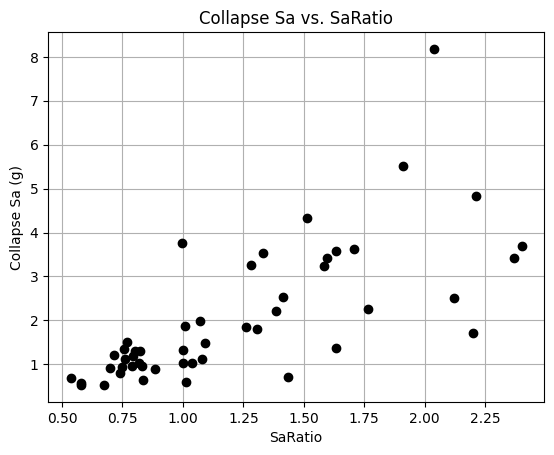

In [53]:
# get training config
train_config = job_info.get('Training', None)
if train_config is None:
    err_msg = 'run_saf_ida: Training not found in job configuration.'
    saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
# create a training run
saf_ida_job.model_training(input_dir=input_dir, train_config=train_config)
saf_ida_job.saf_model.plot_raw_collapse(logscale=[False,False])

In [54]:
print(saf_ida_job.saf_model.col_model.model.coef_)

[1.3138277]


In [55]:
print(saf_ida_job.saf_model.col_model.model.intercept_)

0.3337015783973455


In [56]:
# get training config
pred_config = job_info.get('Prediction', None)
if pred_config is None:
    err_msg = 'run_saf_ida: Prediction not found in job configuration.'
    saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
# create a training run
saf_ida_job.model_prediction(pred_config=pred_config, output_dir=output_dir)

SiteInfo: site im loaded.
Collapse model received.
EDP models received.
Computing GCIM targets.
self.key_im= ['SaRatio']
self.gcim[tagsite]= {'SaT1': array([1.16183424]), 'SaRatio': array([1.64872127])}
GCIM targets computed.
Adjusting EDP: SDRmax-story1 for LosAngeles
Adjusted median of SDRmax-story1 at RP2475: 0.0054660951378181655
Adjusted std of SDRmax-story1 at RP2475: 0.3512003506476339
Adjusting EDP: SDRmax-story2 for LosAngeles
Adjusted median of SDRmax-story2 at RP2475: 0.009406051404968592
Adjusted std of SDRmax-story2 at RP2475: 0.25983235786477044
Adjusting EDP: SDRmax-story3 for LosAngeles
Adjusted median of SDRmax-story3 at RP2475: 0.011121910576539091
Adjusted std of SDRmax-story3 at RP2475: 0.2225299956073286
Adjusting EDP: SDRmax-story4 for LosAngeles
Adjusted median of SDRmax-story4 at RP2475: 0.012349700737630951
Adjusted std of SDRmax-story4 at RP2475: 0.1961076223361306
Adjusting EDP: SDRmax-story5 for LosAngeles
Adjusted median of SDRmax-story5 at RP2475: 0.013312